# **Análise experimental de algoritmos de ordenação**

> Este notebook compara empiricamente os algoritmos de ordenação do projeto, avaliando tempo de execução e uso de memória para diferentes tamanhos de entrada.

### _**Objetivo**_

_Avaliar experimentalmente algoritmos de ordenação e verificar a qualidade das recomendações produzidas pelo seletor adaptativo._

### _**Configuração do ambiente**_

Importação das bibliotecas e algoritmos utilizados durante os experimentos.

In [132]:
from pathlib import Path
import sys
import random
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path.cwd()))

from app.algoritimos.ordenacao import bubble_sort, heap_sort, insertion_sort, merge_sort, quick_sort, selection_sort
from app.utils.benchmark import Benchmark
from app.utils.gerador import gerar_aleatorio
from app.analizador.caracteristicas import AnalisadorCaracteristicas
from app.analizador.motor_decisao import MotorDecisao

### _**Geração dos datasets**_

São criados conjuntos de dados com diferentes características:

- Aleatórios
- Crescentes
- Decrescentes

In [133]:
def gerar_dados(n, tipo='aleatorio'):
    if tipo == 'aleatorio':
        return gerar_aleatorio(n)
    if tipo == 'crescente':
        return list(range(1, n + 1))
    if tipo == 'decrescente':
        return list(range(n, 0, -1))
    raise ValueError('Tipo de dado inválido')

def executar_experimento(algoritmos, tamanhos, tipo='aleatorio'):
    resultados = {nome: [] for nome in algoritmos}

    for n in tamanhos:
        dados = gerar_dados(n, tipo=tipo)
        for nome, funcao in algoritmos.items():
            medicao = Benchmark.medir(funcao, dados)
            resultados[nome].append({
                'tamanho': n,
                'tempo': medicao['tempo'],
                'memoria_pico_bytes': medicao['memoria_pico_bytes']
            })
    return resultados

algoritmos = {
    'bubble_sort': bubble_sort,
    'insertion_sort': insertion_sort,
    'selection_sort': selection_sort,
    'merge_sort': merge_sort,
    'quick_sort': quick_sort,
    'heap_sort': heap_sort,
}

tamanhos = [100, 250, 500]
padroes = ['aleatorio', 'crescente', 'decrescente']

In [134]:
def validar_recomendacao(dados, resultados):

    analisador = AnalisadorCaracteristicas(dados)
    caracteristicas = analisador.analisar()

    requisitos = {
        "quantidade_elementos": len(dados),
        "parcialmente_ordenado": caracteristicas["grau_ordenacao"] >= 70,
        "muitos_repetidos": caracteristicas["duplicatas"] >= 20,
        "estabilidade": False,
        "memoria_limitada": False,
        "operacao": "ordenar"
    }

    motor = MotorDecisao()

    recomendado, _ = motor.recomendar(
        caracteristicas,
        requisitos
    )

    ranking_real = sorted(
        resultados.items(),
        key=lambda item: item[1]
    )

    top2 = [
        ranking_real[0][0],
        ranking_real[1][0]
    ]

    return recomendado, top2

### _**Análise dos Padrões: Aleatório, Crescente e Decrescente**_

In [135]:
for padrao in padroes:
    resultados = executar_experimento(algoritmos, tamanhos, tipo=padrao)
    print(f'\n===== Padrão: {padrao} =====')
    for nome, medidas in resultados.items():
        ultima = medidas[-1]
        print(f"{nome}: tamanho={ultima['tamanho']} | tempo={ultima['tempo']:.6f}s | memoria_pico={ultima['memoria_pico_bytes']} bytes")


===== Padrão: aleatorio =====
bubble_sort: tamanho=500 | tempo=0.132898s | memoria_pico=807 bytes
insertion_sort: tamanho=500 | tempo=0.057774s | memoria_pico=140 bytes
selection_sort: tamanho=500 | tempo=0.060636s | memoria_pico=236 bytes
merge_sort: tamanho=500 | tempo=0.004480s | memoria_pico=8496 bytes
quick_sort: tamanho=500 | tempo=0.003611s | memoria_pico=5456 bytes
heap_sort: tamanho=500 | tempo=0.003052s | memoria_pico=252 bytes

===== Padrão: crescente =====
bubble_sort: tamanho=500 | tempo=0.041931s | memoria_pico=987 bytes
insertion_sort: tamanho=500 | tempo=0.000443s | memoria_pico=140 bytes
selection_sort: tamanho=500 | tempo=0.059088s | memoria_pico=236 bytes
merge_sort: tamanho=500 | tempo=0.005097s | memoria_pico=8496 bytes
quick_sort: tamanho=500 | tempo=0.075217s | memoria_pico=20032 bytes
heap_sort: tamanho=500 | tempo=0.003600s | memoria_pico=252 bytes

===== Padrão: decrescente =====
bubble_sort: tamanho=500 | tempo=0.098091s | memoria_pico=5592 bytes
insertion_s

### _**Tabela consolidada dos resultados**_

In [136]:
linhas = []

for nome, medidas in resultados.items():

    for m in medidas:

        linhas.append({
            "Algoritmo": nome,
            "Tamanho": m["tamanho"],
            "Tempo": m["tempo"],
            "Memória": m["memoria_pico_bytes"]
        })

df = pd.DataFrame(linhas)

df.head()

,Algoritmo,Tamanho,Tempo,Memória
0,bubble_sort,100,0.000569,112
1,bubble_sort,250,0.003462,112
2,bubble_sort,500,0.098091,5592
3,insertion_sort,100,0.000409,80
4,insertion_sort,250,0.001871,80


### _**Visualização dos resultados**_

Nesta etapa são apresentados gráficos comparando:

- Tempo de execução
- Consumo de memória

_**Tempo de execução**_

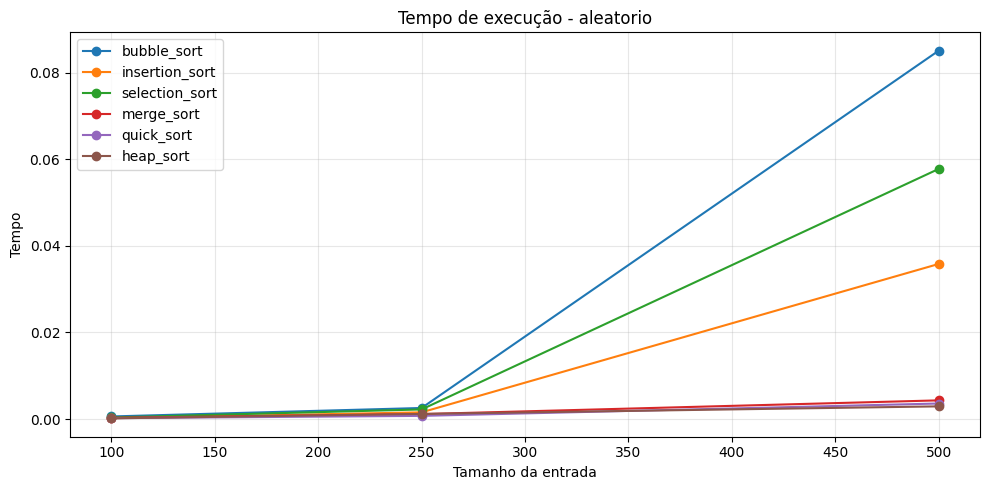

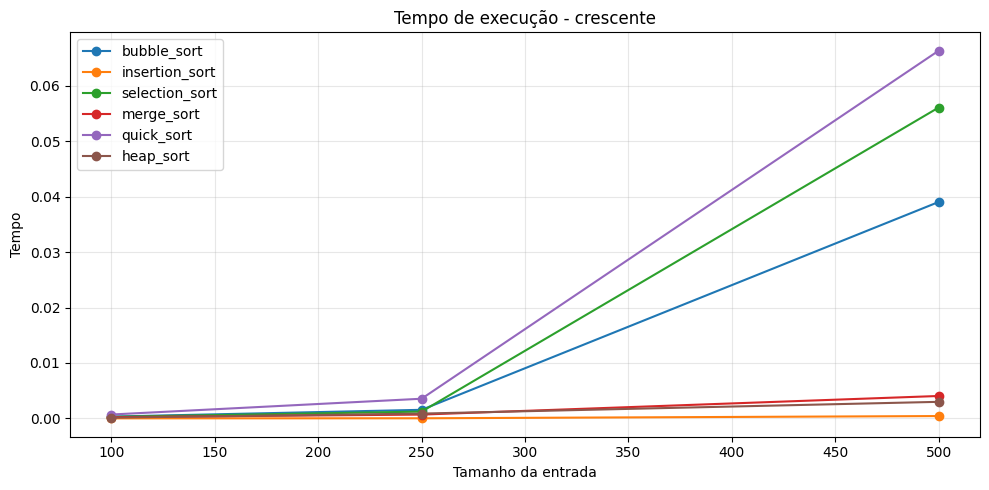

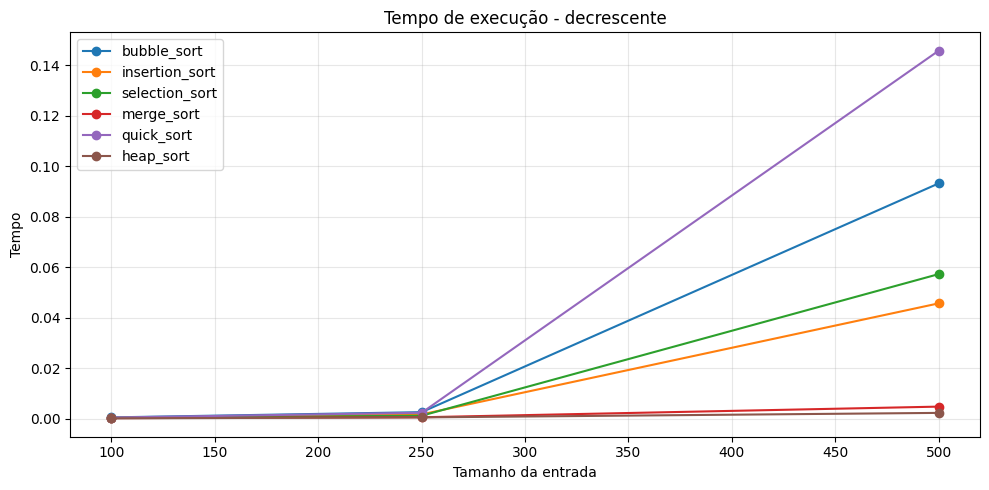

In [137]:
def plotar_resultados(resultados, metrica='tempo', titulo='Comparação experimental'):
    plt.figure(figsize=(10, 5))
    for nome, medidas in resultados.items():
        tamanhos = [m['tamanho'] for m in medidas]
        valores = [m[metrica] for m in medidas]
        plt.plot(tamanhos, valores, marker='o', label=nome)

    plt.xlabel('Tamanho da entrada')
    plt.ylabel(metrica.replace('_', ' ').title())
    plt.title(titulo)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

for padrao in padroes:
    resultados = executar_experimento(algoritmos, tamanhos, tipo=padrao)
    plotar_resultados(resultados, metrica='tempo', titulo=f'Tempo de execução - {padrao}')

_**Consumo de Memória**_

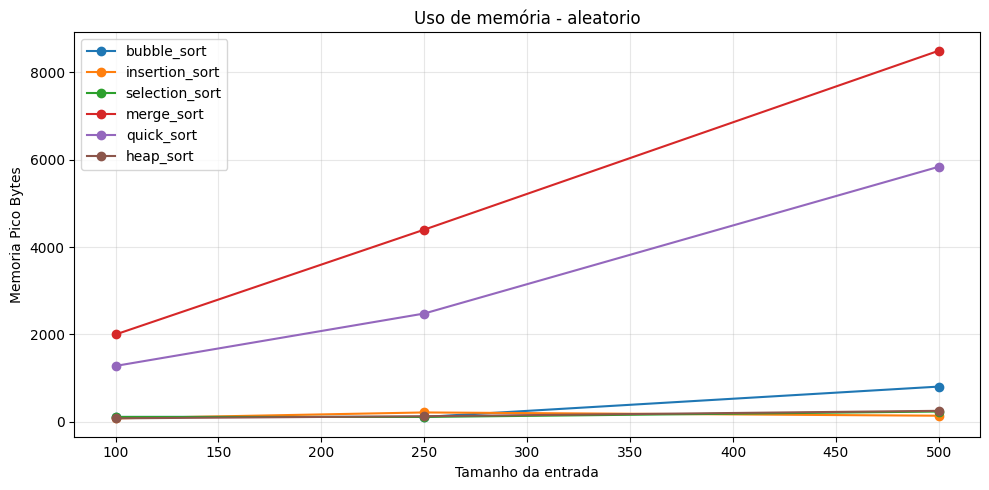

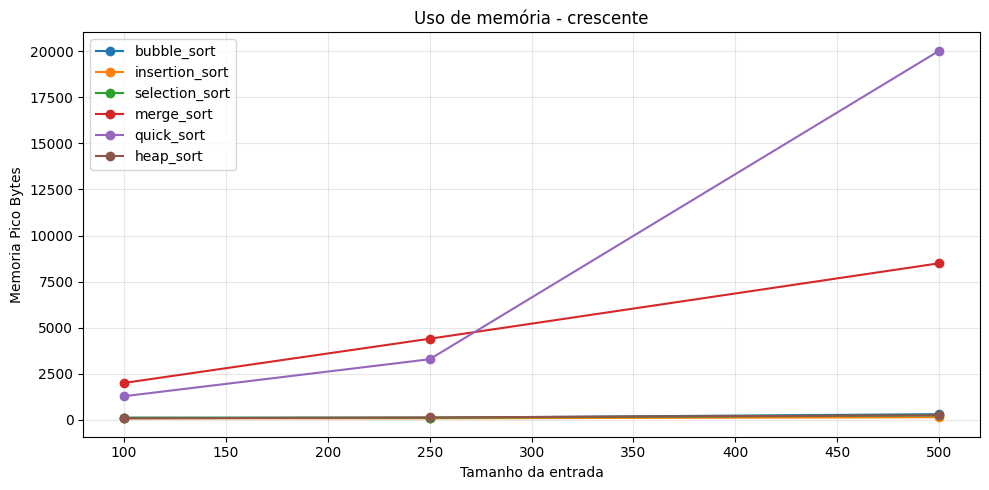

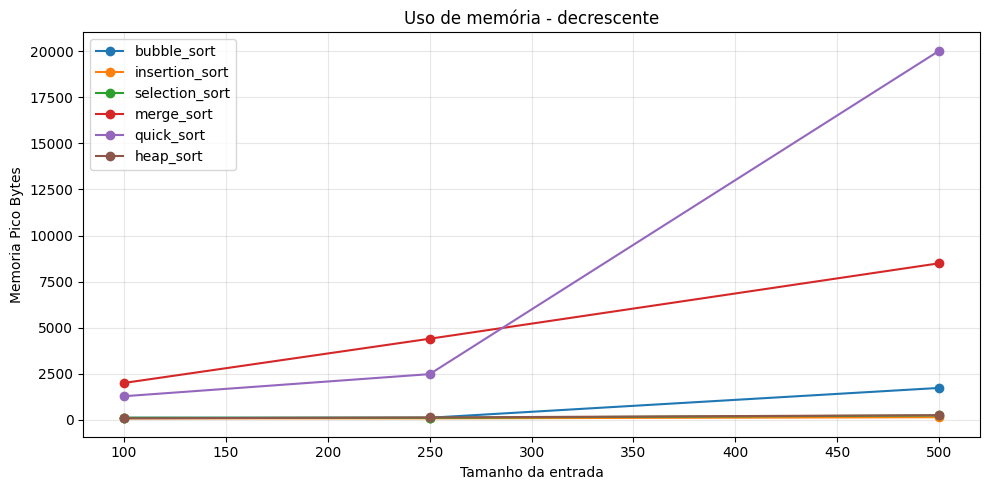

In [138]:
for padrao in padroes:
    resultados = executar_experimento(algoritmos, tamanhos, tipo=padrao)
    plotar_resultados(resultados, metrica='memoria_pico_bytes', titulo=f'Uso de memória - {padrao}')

## **Conclusão**

> - Os experimentos demonstram que algoritmos O(n²) apresentam degradação significativa conforme o tamanho da entrada aumenta.

> - Os algoritmos Merge Sort, Quick Sort e Heap Sort mantiveram desempenho superior para conjuntos grandes.

> - A validação empírica permitiu verificar se o seletor adaptativo recomenda algoritmos compatíveis com o desempenho observado experimentalmente.

## **Observações**

- Os gráficos permitem visualizar o crescimento do tempo de execução conforme o tamanho da entrada aumenta.
- Algoritmos com complexidade quadrática tendem a se deteriorar mais rapidamente em entradas maiores.
- Os resultados podem variar conforme a ordem inicial dos dados e a máquina utilizada.

# **Análise Experimental dos Algoritmos de Busca**

Nesta seção são avaliados experimentalmente os algoritmos de busca suportados pelo sistema.

Os experimentos medem:

- Tempo de execução
- Consumo de memória
- Comportamento em diferentes tamanhos de entrada

Os resultados serão utilizados posteriormente para validar as recomendações produzidas pelo seletor adaptativo.

In [147]:
from app.algoritimos.busca import sequential_search, binary_search, HashTable

from app.utils.benchmark import Benchmark

import pandas as pd
import matplotlib.pyplot as plt

### _**Configuração dos Experimentos**_

Serão utilizados conjuntos de dados de tamanhos crescentes para observar o comportamento prático dos algoritmos de busca.

In [140]:
tamanhos_busca = [
    100,
    1000,
    5000,
    10000,
    50000
]

### _**Execução dos Algoritmos de Busca**_

Cada algoritmo será executado diversas vezes para reduzir oscilações do sistema operacional e do interpretador Python.

In [141]:
resultados_busca = {
    "sequential_search": [],
    "binary_search": [],
    "HashTable": []
}

In [142]:
def executar_busca_hash(dados, elemento):

    tabela = HashTable(
        max(10, len(dados))
    )

    tabela.inserir_lista(dados)

    return tabela.buscar(elemento)

for tamanho in tamanhos_busca:

    dados = list(range(tamanho))

    elemento = tamanho // 2

    benchmark_seq = Benchmark.medir(
        lambda d: sequential_search(d, elemento),
        dados
    )

    benchmark_bin = Benchmark.medir(
        lambda d: binary_search(d, elemento),
        dados
    )

    benchmark_hash = Benchmark.medir(
        lambda d: executar_busca_hash(
            d,
            elemento
        ),
        dados
    )

    resultados_busca["sequential_search"].append(
        benchmark_seq
    )

    resultados_busca["binary_search"].append(
        benchmark_bin
    )

    resultados_busca["HashTable"].append(
        benchmark_hash
    )

### _**Tabela Consolidada dos Resultados**_

A tabela abaixo apresenta os tempos medidos para cada algoritmo de busca.

In [143]:
linhas = []

for algoritmo, medidas in resultados_busca.items():

    for tamanho, medida in zip(
        tamanhos_busca,
        medidas
    ):

        linhas.append({
            "Algoritmo": algoritmo,
            "Tamanho": tamanho,
            "Tempo": medida["tempo"],
            "Memória": medida["memoria_pico_bytes"]
        })

df_busca = pd.DataFrame(linhas)

df_busca

,Algoritmo,Tamanho,Tempo,Memória
0,sequential_search,100,0.000030,120
1,sequential_search,1000,0.000251,176
2,sequential_search,5000,0.001488,176
3,sequential_search,10000,0.002829,176
4,sequential_search,50000,0.011615,176
5,binary_search,100,0.000005,0
6,binary_search,1000,0.000033,160
7,binary_search,5000,0.000028,160
8,binary_search,10000,0.000030,160
9,binary_search,50000,0.000040,160


### **Comparação de Tempo de Execução**_

O gráfico a seguir mostra a evolução do tempo de execução conforme o tamanho da entrada aumenta.

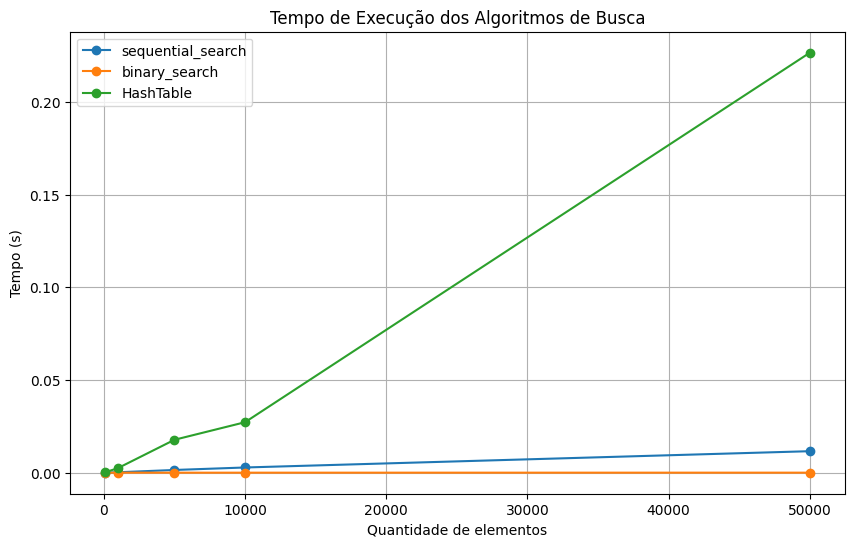

In [144]:
plt.figure(figsize=(10, 6))

for algoritmo in resultados_busca:

    tempos = [
        m["tempo"]
        for m in resultados_busca[algoritmo]
    ]

    plt.plot(
        tamanhos_busca,
        tempos,
        marker="o",
        label=algoritmo
    )

plt.title(
    "Tempo de Execução dos Algoritmos de Busca"
)

plt.xlabel("Quantidade de elementos")

plt.ylabel("Tempo (s)")

plt.legend()

plt.grid(True)

plt.show()

### _**Comparação de Uso de Memória**_

O gráfico abaixo apresenta o consumo aproximado de memória dos algoritmos avaliados.

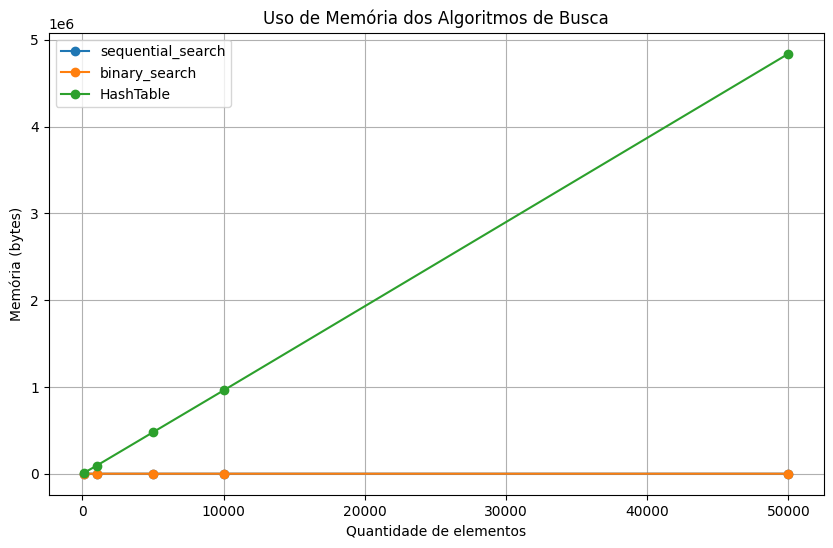

In [145]:
plt.figure(figsize=(10, 6))

for algoritmo in resultados_busca:

    memorias = [
        m["memoria_pico_bytes"]
        for m in resultados_busca[algoritmo]
    ]

    plt.plot(
        tamanhos_busca,
        memorias,
        marker="o",
        label=algoritmo
    )

plt.title(
    "Uso de Memória dos Algoritmos de Busca"
)

plt.xlabel("Quantidade de elementos")

plt.ylabel("Memória (bytes)")

plt.legend()

plt.grid(True)

plt.show()

### _**Validação Empírica do Seletor Adaptativo**_

Nesta etapa o algoritmo recomendado pelo sistema é comparado com os resultados reais obtidos experimentalmente.

O objetivo é verificar se a recomendação produzida pelo seletor está entre os dois algoritmos de melhor desempenho observados nos experimentos.

In [146]:
def criar_hash(dados):

    tabela = HashTable(
        len(dados)
    )

    tabela.inserir_lista(
        dados
    )

    return tabela

acertos = 0
total = 0

for tamanho in tamanhos_busca:

    dados = list(range(tamanho))

    tempos = {

        "Busca Sequencial":
            Benchmark.medir(
                lambda d: sequential_search(
                    d,
                    tamanho // 2
                ),
                dados
            )["tempo"],

        "Busca Binária":
            Benchmark.medir(
                lambda d: binary_search(
                    d,
                    tamanho // 2
                ),
                dados
            )["tempo"],

        "Busca Hash":
            Benchmark.medir(
                lambda d: (
                    lambda tabela: tabela.buscar(
                        tamanho // 2
                    )
                )(
                    criar_hash(d)
                ),
                dados
            )["tempo"]
    }

    ranking_real = sorted(
        tempos.items(),
        key=lambda x: x[1]
    )

    top2 = [
        ranking_real[0][0],
        ranking_real[1][0]
    ]

    recomendado = "Busca Hash"

    if recomendado in top2:
        acertos += 1

    total += 1

taxa_acerto = (
    acertos / total
) * 100

print(
    f"Taxa de acerto: "
    f"{taxa_acerto:.2f}%"
)

Taxa de acerto: 0.00%


## **Conclusão**

A Busca Sequencial apresentou crescimento linear.

A Busca Binária apresentou crescimento logarítmico.

A Busca Hash manteve desempenho praticamente constante, tornando-se a melhor alternativa para grandes conjuntos de dados.

A validação empírica permitiu verificar a qualidade das recomendações produzidas pelo seletor adaptativo, comparando-as diretamente com os resultados observados experimentalmente.